## Topics covered in this notebook

1. Coordinate transforms in practice.
2. Geometrical delay.
3. Flat-sky approximation
4. Beamforming
5. Consequences of assumptions being broken (causes in next notebooks)

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import radio_tools as rt
import astropy.units as u

we need to know where our baseline vector points, and where the source points.

so I need position of my antenna on earth, and position of the source on the sky.

First let's load antenna positions. Often they're specified in two different ways. 
1. Location on a horizontal grid with respect to some reference point (or reference antenna.) Common for many planar arrays. Imagine taking a ruler and literally measuring distance along the ground. Or may be use laser ranging.
2. For much bigger arrays, in LBI and VLBI, that's not possible. So the antenna positions will be specified using Geodetic coordinates, i.e. latitude, longitude, and elevation or geocentric coordinates x,y,z where x is Greenwich and z is north pole. These are usually measured with very high precision using fancy GPS surveying technqiues like RTK/PPK and/or PPP.

Astronomical sources are often specified in the International Celestial Refernce System using Right Ascension (RA) and Declination (Dec).

Using these two pieces of information we can calculate what the differential light travel time to any pair of antennas (baseline) is.

In [2]:
#Let's look at HERA, specified using distance from reference location.
hera = np.genfromtxt(
    "hera_ant_pos.csv",
    delimiter=",",
    names=True,
    dtype=None,
    encoding="utf-8"
)
hera_xyz = np.asarray([hera['x'],hera['y'],hera['z']]).T.copy() # xyz along columns
#print(hera["x"], hera["y"], hera["z"])
#Let's also load the reference location for these antennas, which will be useful later.
hera_ref = EarthLocation.from_geodetic(lat='−30.72152612068925°', lon='21.42830382686301°',height='1051.69 m')

In [3]:
# we'd now like to generate antenna locations in ENU system centered at the reference location. 
# A good trick for quick calculations is as follows
# This assumes a spherical Earth (will be relevant later.)

up=hera_ref.itrs.cartesian.xyz #that's a vector up thru the ref
up=up/np.sqrt(up@up) #unit vector now

# [1,0,0] = lon = 0 is greenwich, with east +ve and west -ve. So local east vector is just 
# [0,1,0] rotated by longitude
ea=np.asarray([-np.sin(hera_ref.lon.rad), np.cos(hera_ref.lon.rad), 0]) 

#and north is finally just the cross product in a right handed coord. system.
nr=np.cross(up,ea)

mat = np.vstack([ea,nr,up]).T
hera_enu_quick = hera_xyz@mat

In [4]:
#let's also get it the proper way without assuming a spherical earth.
hera_enu = rt.itrs_to_enu(hera_xyz, hera_ref.lat.deg, hera_ref.lon.deg)

Text(0, 0.5, 'north (m)')

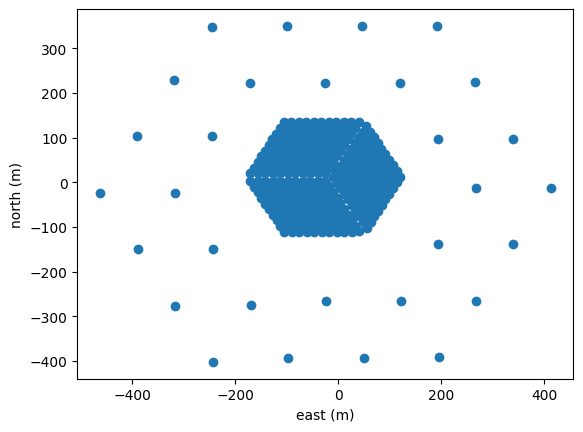

In [5]:
plt.scatter(hera_enu[:,0],hera_enu[:,1])
plt.xlabel("east (m)")
plt.ylabel("north (m)")

In [6]:
print("error in proper vs quick ENU calc", np.std(hera_enu-hera_enu_quick), "m")
print("Where on Earth will this matter?")

error in proper vs quick ENU calc 0.16714423340585227 m
Where on Earth will this matter?


In [7]:
# Let's generate baselines now. There's gonna be a LOT of them. How many?
nant = hera_xyz.shape[0]
nbl = nant * (nant-1)//2
print("num bl is", nbl)

# how to quickly get baselines the numpy vectorized way? laziness is good.
# baselines are just the upper triangle of a nant x nant array
ix = np.triu_indices(nant,k=1) #offset of 1 since main diagonal is autos
print(ix)

num bl is 61075
(array([  0,   0,   0, ..., 347, 347, 348], shape=(61075,)), array([  1,   2,   3, ..., 348, 349, 349], shape=(61075,)))


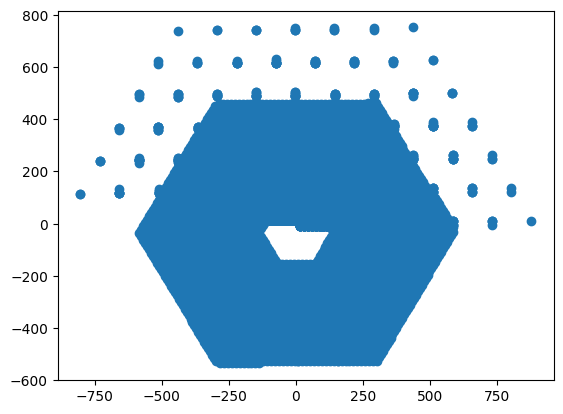

In [8]:
hera_bl_enu = hera_enu[ix[1]]-hera_enu[ix[0]] #and...done!
#let's plot the baselines

plt.scatter(hera_bl_enu[:,0], hera_bl_enu[:,1]) #only upper triangle, all unique pairs

In [21]:
# Let's say it's operating at 150 MHz, and each dish is 14 m wide.
# what's the FoV of one dish, and what's the rough resolution of the array?
nu=150e6
lm = 3e8/nu #m
d = 14 #m dish size
max_bl = np.max(np.sqrt(np.sum(hera_bl_enu**2,axis=1)))
res = lm/max_bl #max baseline
fov = lm/d

print(f"Synth. beam res\t: {np.rad2deg(res)*60:4.2f} arcmin\nFOV\t\t: {np.rad2deg(fov):4.2f} deg")

Synth. beam res	: 7.84 arcmin
FOV		: 8.19 deg


In [82]:
# before we make PSFs let's first see what the interferometer sees if I just turn it ON.

# to answer that, we must answer what geometrical delay does any baselines measure?
# let's try to look at Cen A
# Since our baselines are in topocentric (ENU) system, we need to know where the source is on the sky in that system.
# Remember: origin is at the reference position. 

# a small exercise

nside=512
npix=hp.nside2npix(nside)
resol=hp.nside2resol(nside,arcmin=True)
res=hp.nside2resol(nside,arcmin=True)
co_dec,ra=hp.pix2ang(nside,np.arange(npix))
dec=np.pi/2-co_dec
tstart = 1753200150 #random datetime, you can choose your favorite, just make sure the source is risen!
obstime=Time(tstart,format="unix",scale="utc")
src = SkyCoord(ra=ra*u.rad, dec=dec*u.rad, frame='icrs')
azalt =src.transform_to(AltAz(location=hera_ref,obstime=obstime))
setsrc=azalt.alt.deg<0
delays = rt.geo_delay_from_enu(hera_bl_enu[[5,5519],:],azalt.az.rad,azalt.alt.rad)
delays[0,setsrc]=np.nan

cenA = SkyCoord(ra='13h 25m 27.6150s',dec='−43° 01′ 08.806″', frame='icrs') 

azalt_cenA = cenA.transform_to(AltAz(location=hera_ref,obstime=obstime))
delays_cenA = rt.geo_delay_from_enu(hera_bl_enu[[5,5519],:],np.asarray([azalt_cenA.az.rad]),np.asarray([azalt_cenA.alt.rad]))
# To get the delay measured by each baseline, now we just take a dot product! see the code


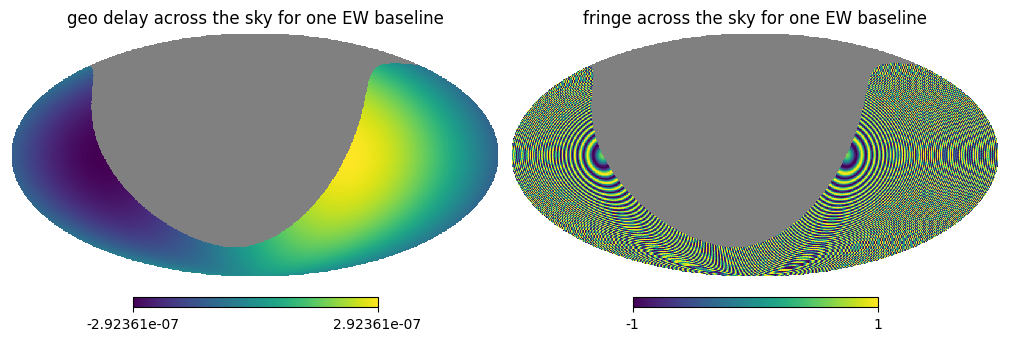

In [22]:
fig=plt.gcf()
fig.set_size_inches(10,4)
hp.mollview(delays[0], title="geo delay across the sky for one EW baseline",fig=fig.number,sub=121)
hp.mollview(np.cos(2*np.pi*nu*delays[0]), title="fringe across the sky for one EW baseline",fig=fig.number,sub=122)

Fringe pattern looks really complicated on the full, curved sky, but HERA dishes aren't seeing the whole sky. Let's zoom in near Cen A, which is close to zenith at the time chosen for a patch the size of HERA's primary beam.

71.47556745551285
expect about 6.138833519258819 cycles per primary beam
expect about 3.637827270671893 cycles per primary beam


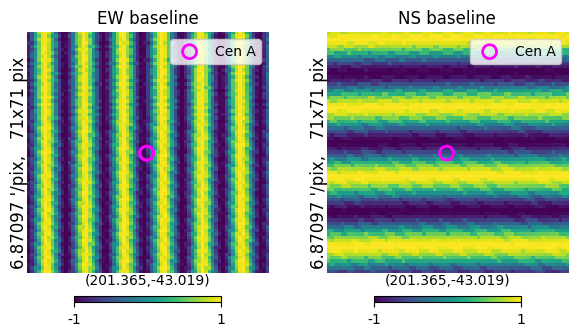

In [33]:
xsize = np.rad2deg(fov)*60/resol
print(xsize)

fig = plt.figure(figsize=(6, 3))
fringe = np.exp(2j * np.pi * 150e6 * delays[0])
hp.gnomview(fringe.real, rot=(cenA.ra.deg, cenA.dec.deg),reso=resol,xsize=xsize,fig=fig.number,sub=121,title='EW baseline')

hp.projscatter(cenA.ra.deg, cenA.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=2,             # Line width
               label='Cen A')
plt.legend()
fringe = np.exp(2j * np.pi * 150e6 * delays[1])
hp.gnomview(fringe.real, rot=(cenA.ra.deg, cenA.dec.deg),reso=resol,xsize=xsize, fig=fig.number,sub=122, title='NS baseline')
hp.projscatter(cenA.ra.deg, cenA.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=2,             # Line width
               label='Cen A')
plt.legend()



We see that the fringe spacing is proportional to baseline length, and also that it looks very much like a periodic sine wave. So, if a dish only sees a small patch of the sky, the interferometer measures the sky * sine wave.

The sine/cosine waves in 2D are $e^{j2\pi(u l + v m)}$ where u, v are baseline lengths in units of wavelengths and l and m are direction cosines that reduce to angular distance in small patch limit.

In [41]:
#what's the expected fringe spacing for the EW and NS baseline?
u=np.rad2deg(lm/hera_bl_enu[5, 0])*60 
print(f"expect about {xsize*resol/u:.1f} cycles per primary beam along EW")
v=np.rad2deg(lm/hera_bl_enu[5519, 1])*60
print(f"expect about {xsize*resol/v:.1f} cycles per primary beam along NS")

expect about 6.3 cycles per primary beam along EW
expect about 3.6 cycles per primary beam along NS


This lines up with what the zoomed in images show.

### Beamforming

71.47556745551285


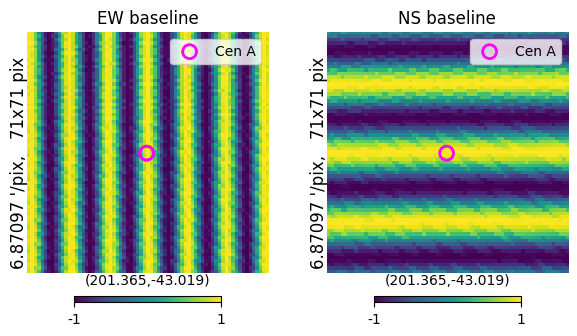

In [63]:
xsize = np.rad2deg(fov)*60/resol
print(xsize)

fig = plt.figure(figsize=(6, 3))
fringe = np.exp(2j * np.pi * 150e6 * (delays[0]-delays_cenA[0]))
hp.gnomview(fringe.real, rot=(cenA.ra.deg, cenA.dec.deg),reso=resol,xsize=xsize,fig=fig.number,sub=121,title='EW baseline')

hp.projscatter(cenA.ra.deg, cenA.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=2,             # Line width
               label='Cen A')
plt.legend()
fringe = np.exp(2j * np.pi * 150e6 *(delays[1]-delays_cenA[1]))
hp.gnomview(fringe.real, rot=(cenA.ra.deg, cenA.dec.deg),reso=resol,xsize=xsize, fig=fig.number,sub=122, title='NS baseline')
hp.projscatter(cenA.ra.deg, cenA.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=2,             # Line width
               label='Cen A')
plt.legend()



how fast is Centaurus A moving through the sky? Let's look at Cen A 2 minutes later but NOT update our phase center.

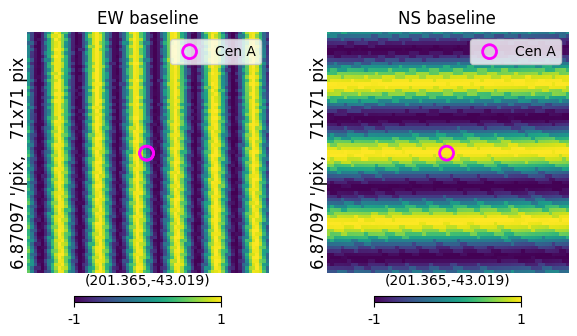

In [83]:
obstime=Time(1753200150+120,format="unix",scale="utc")
azalt = src.transform_to(AltAz(location=hera_ref,obstime=obstime))
delays = rt.geo_delay_from_enu(hera_bl_enu[[5,5519],:],azalt.az.rad,azalt.alt.rad)
delays[0,setsrc]=np.nan

fig = plt.figure(figsize=(6, 3))
fringe = np.exp(2j * np.pi * 150e6 * (delays[0]-delays_cenA[0])) #still the OLD PHASE CENTERING
hp.gnomview(fringe.real, rot=(cenA.ra.deg, cenA.dec.deg),reso=resol,xsize=xsize,fig=fig.number,sub=121,title='EW baseline')

hp.projscatter(cenA.ra.deg, cenA.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=2,             # Line width
               label='Cen A')
plt.legend()
fringe = np.exp(2j * np.pi * 150e6 *(delays[1]-delays_cenA[1]))
hp.gnomview(fringe.real, rot=(cenA.ra.deg, cenA.dec.deg),reso=resol,xsize=xsize, fig=fig.number,sub=122, title='NS baseline')
hp.projscatter(cenA.ra.deg, cenA.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=2,             # Line width
               label='Cen A')
plt.legend()

We see that Cen A has drifted out of the phase center of the EW baseline in ~100 seconds. It we let it drift, then we'll be averaging over several cycles of a sine wave, leading to ~0 at the interferometer output. As a rule of thumb, for tracking arrays, the phase center must be updated at a rate that's at least 10x the rate of change of delay of the source being tracked.

(NOTE: HERA cannot track, we're just assuming it can.)

### Projection of baselines

Now let's look at Cen A a few hours later with the same two baselines. It has moved to be much lower in the topocentric sky, very close to zenith, just before setting.

New azalt 225.66314219118132 10.52206570312239


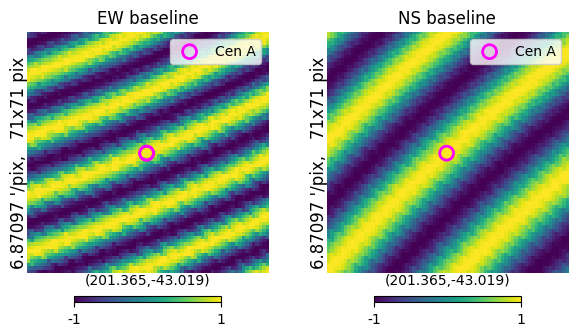

In [87]:
obstime=Time(1753200150+25000,format="unix",scale="utc") #9 hours later
azalt = src.transform_to(AltAz(location=hera_ref,obstime=obstime))
delays = rt.geo_delay_from_enu(hera_bl_enu[[5,5519],:],azalt.az.rad,azalt.alt.rad)
delays[0,setsrc]=np.nan

azalt_cenA = cenA.transform_to(AltAz(location=hera_ref,obstime=obstime))
print("New azalt", azalt_cenA.az.deg, azalt_cenA.alt.deg)
delays_cenA_new = rt.geo_delay_from_enu(hera_bl_enu[[5,5519],:],np.asarray([azalt_cenA.az.rad]),np.asarray([azalt_cenA.alt.rad]))

fig = plt.figure(figsize=(6, 3))
fringe = np.exp(2j * np.pi * 150e6 * (delays[0]-delays_cenA_new[0]))
hp.gnomview(fringe.real, rot=(cenA.ra.deg, cenA.dec.deg),reso=resol,xsize=xsize,fig=fig.number,sub=121,title='EW baseline')

hp.projscatter(cenA.ra.deg, cenA.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=2,             # Line width
               label='Cen A')
plt.legend()
fringe = np.exp(2j * np.pi * 150e6 *(delays[1]-delays_cenA_new[1]))
hp.gnomview(fringe.real, rot=(cenA.ra.deg, cenA.dec.deg),reso=resol,xsize=xsize, fig=fig.number,sub=122, title='NS baseline')
hp.projscatter(cenA.ra.deg, cenA.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=2,             # Line width
               label='Cen A')
plt.legend()

### What changes do we notice?

Remember that we started from the actual, full geometrical delay but saw that a simple 2-D approximation worked well. This approximation is valid only for a small patch near the phase center when the baselines are in fact planar.

We notice that
1. The fringes have rotated, such that they appear to be a combination of pure NS and EW fringes previously.
2. Period of the fringes is slightly different
3. There's some warping of fringes.

The UV coordinate system is defined on a plane perpendicular to the direction of the source. So a EW baseline will be purely U only when source is right overhead. As the source rotates along azimuth, U and V mix together. 

The length of projected baseline changes as the source gets closer to horizon, which affects the fringe period.

Moreover, the approximation of the full fringe factor $\mathbf{b}.\hat{n}/\lambda$ with $ul + vm$ becomes worse as the source approaches the horizon because the $w$ term is not negligible anymore. We'll see this in the next notebook.